# Avatar Generation

Generate pixel-art cat avatars from the `image_prompt` field produced in notebook 03.
We use Hugging Face Inference Providers with FLUX.1-schnell via fal.ai for fast, cheap inference.

## Setup

In [5]:
import os
from huggingface_hub import InferenceClient
from PIL import Image

## Prompt template

The `image_prompt` from card generation describes the subject concisely (e.g. "Siamese cat, light brown and cream fur, stealthy pose"). We wrap it with a pixel-art style instruction.

In [6]:
def build_avatar_prompt(subject_prompt: str) -> str:
    return (
        f"Generate a pixel-art avatar for a game character. "
        f"The character: {subject_prompt}. "
        f"Style: pixel-art game sprite, 64x64 pixels, transparent background, "
        f"facing forward, centred, clean outlines, vibrant colours, no text, no UI elements."
    )

## Generate avatar

Make sure `HF_TOKEN` is set in the environment. Get one at https://huggingface.co/settings/tokens with "Make calls to inference providers" enabled.

We use FLUX.1-schnell via the fal.ai provider — fast (~1s) and cheap ($0.001/image).

Avatar size: (1024, 768), mode: RGB


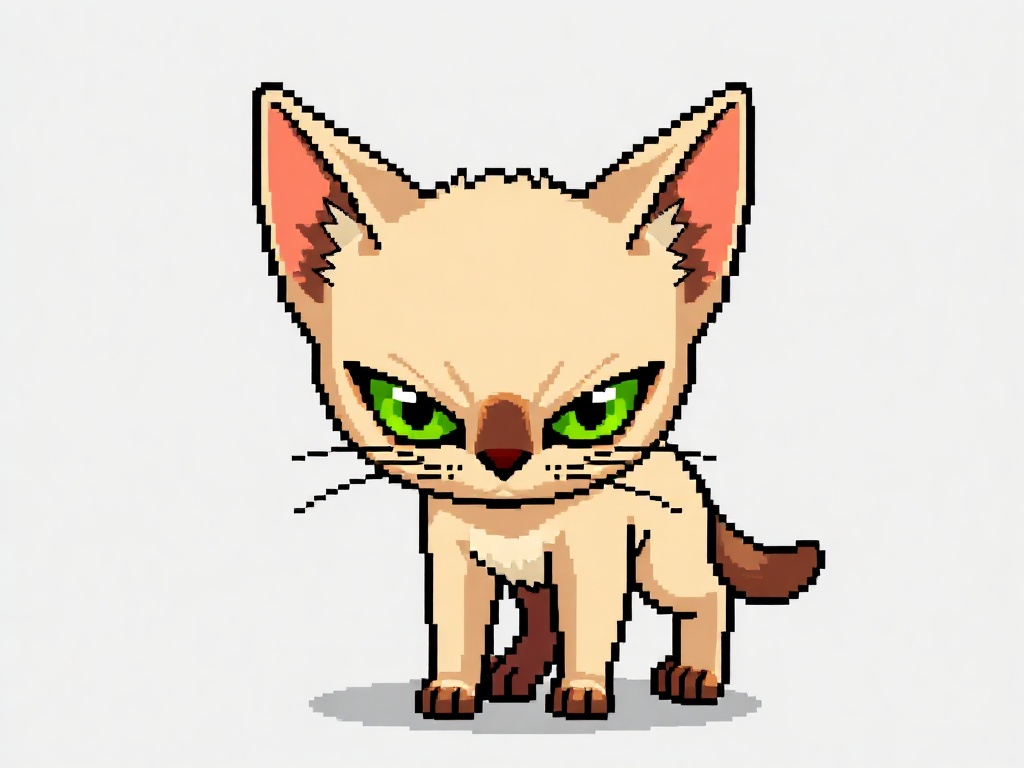

In [7]:
client = InferenceClient(
    provider="fal-ai",
    api_key=os.environ["HUGGINGFACE_API_KEY"],
)

prompt = build_avatar_prompt(
    "Siamese cat, light brown and cream fur, stealthy pose, green eyes"
)

avatar = client.text_to_image(
    prompt,
    model="black-forest-labs/FLUX.1-schnell",
)

print(f"Avatar size: {avatar.size}, mode: {avatar.mode}")
display(avatar)

## Saving to disk

Once validated, the avatar gets uploaded to Supabase Storage and the URL is stored in `cat.avatar_url`. Local save is useful for inspection.

In [8]:
if avatar:
    avatar.save("_sample_avatar.png")
    print("Saved _sample_avatar.png")
else:
    print("No avatar to save.")

Saved _sample_avatar.png


## Wrapping up

This logic feeds directly into `backend/services/avatar_generator.py`. The backend service will:
1. Build the prompt from `image_prompt`
2. Call HF Inference Providers (`FLUX.1-schnell` via fal.ai) and get the PIL image
3. Upload the PNG bytes to Supabase Storage
4. Return the public URL to be stored in `cat.avatar_url`